In [1]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F
import psutil
import logging
import imageio.v2 as imageio
import time

device = "cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(device)
torch.cuda.empty_cache()

cuda:0


In [2]:
logging.basicConfig(
    filename="memory_log.txt",
    level=logging.INFO,
    format="%(asctime)s %(message)s"
)

def log_memory(tag=""):
    process = psutil.Process(os.getpid())
    cpu_mem = process.memory_info().rss / 1024**3

    if torch.cuda.is_available():
        gpu_alloc = torch.cuda.memory_allocated() / 1024**3
        gpu_reserved = torch.cuda.memory_reserved() / 1024**3
    else:
        gpu_alloc = gpu_reserved = 0

    logging.info(
        f"{tag} | CPU {cpu_mem:.3f} GB | GPU alloc {gpu_alloc:.3f} GB | GPU reserved {gpu_reserved:.3f} GB"
    )

In [ ]:
# import urllib.request

# if not os.path.exists('tiny_nerf_data.npz'):
#     url = "http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz"
#     urllib.request.urlretrieve(url, 'tiny_nerf_data.npz')

(106, 100, 100, 3) (106, 4, 4) 138.88887889922103


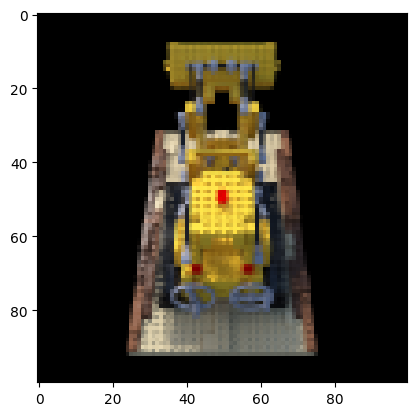

In [ ]:
# data = np.load('tiny_nerf_data.npz')
# images = data['images']
# poses = data['poses']
# focal = data['focal']
# H, W = images.shape[1:3]
# print(images.shape, poses.shape, focal)

# testimg, testpose = images[102], poses[102]
# images = images[:100,...,:3]
# poses = poses[:100]

# images = torch.tensor(images, dtype=torch.float32)
# poses = torch.tensor(poses, dtype=torch.float32)
# testimg = torch.tensor(testimg, dtype=torch.float32)
# testpose = torch.tensor(testpose, dtype=torch.float32)
# focal = torch.tensor(focal, dtype=torch.float32)

# plt.imshow(testimg)
# plt.show()

torch.Size([200, 800, 800, 3]) torch.Size([200, 4, 4]) tensor(1111.1111)


C:\Users\ninos\AppData\Local\Temp\ipykernel_22672\4280045790.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  testimg = torch.tensor(testimg, dtype=torch.float32)
C:\Users\ninos\AppData\Local\Temp\ipykernel_22672\4280045790.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  testpose = torch.tensor(testpose, dtype=torch.float32)


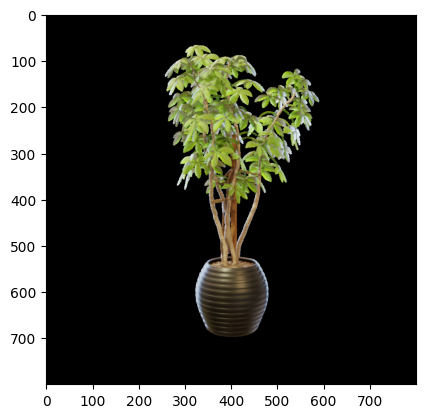

In [ ]:
def load_split(basedir, split):

    with open(os.path.join(basedir, f"transforms_{split}.json"), 'r') as f:
        meta = json.load(f)

    images = []
    poses = []

    for frame in meta["frames"]:
        fname = os.path.join(basedir, frame["file_path"] + ".png")
        images.append(imageio.imread(fname))
        poses.append(frame["transform_matrix"])

    images = np.array(images) / 255.0
    poses = np.array(poses)

    return images, poses, meta

dataset = "hotdog"
basedir = f"nerf_synthetic/{dataset}"

images_train, poses_train, meta = load_split(basedir, "train")
images_val, poses_val, _ = load_split(basedir, "val")

images = np.concatenate([images_train, images_val], axis=0)
poses = np.concatenate([poses_train, poses_val], axis=0)

images = images[..., :3]

images = torch.tensor(images, dtype=torch.float32)
poses = torch.tensor(poses, dtype=torch.float32)

testimg, testpose = images[101], poses[101]

testimg = torch.tensor(testimg, dtype=torch.float32)
testpose = torch.tensor(testpose, dtype=torch.float32)

H, W = images.shape[1:3]
focal = 0.5 * W / np.tan(0.5 * meta["camera_angle_x"])
focal = torch.tensor(focal, dtype=torch.float32)

print(images.shape, poses.shape, focal)
plt.imshow(testimg)
plt.show()

In [6]:
def posenc(x, L_embed):
    rets = [x]
    for i in range(L_embed):
        for fn in [torch.sin, torch.cos]:
            rets.append(fn(2.**i * x))
    return torch.cat(rets, dim=-1)

L_embed_pts = 10
L_embed_views = 4

In [7]:
class NeRF(nn.Module):
    def __init__(self, D=8, W=256, L_pts=10, L_views=4):
        super().__init__()
        self.L_pts = L_pts
        self.L_views = L_views

        input_dim_pts = 3 + 3 * 2 * L_pts
        input_dim_views = 3 + 3 * 2 * L_views

        # Couches pour traiter la position (x, y, z)
        self.pts_layers = nn.ModuleList([nn.Linear(input_dim_pts, W)])
        for i in range(1,D):
            if i == 4:
                self.pts_layers.append(nn.Linear(W + input_dim_pts, W))
            else:
                self.pts_layers.append(nn.Linear(W, W))

        # Sortie de la densité
        self.sigma_layer = nn.Linear(W, 1)

        # Branche pour la couleur
        self.feature_layer = nn.Linear(W, W)
        self.views_layer = nn.Linear(W + input_dim_views, W // 2)
        self.rgb_layer = nn.Linear(W // 2, 3)

    def forward(self, pts_enc, views_enc):
        # Position
        h = pts_enc
        for i, layer in enumerate(self.pts_layers):
            if i == 4:
                h = torch.cat([pts_enc, h], dim=-1)
            h = F.relu(layer(h))
        # On récupère la densité
        sigma = self.sigma_layer(h)
        # On ajoute la direction de vue pour le RGB
        feature = self.feature_layer(h)
        h = torch.cat([feature, views_enc], dim=-1)
        h = F.relu(self.views_layer(h))
        rgb = torch.sigmoid(self.rgb_layer(h))

        return torch.cat([rgb, sigma], dim=-1)

In [8]:
def get_rays(H, W, focal, c2w):
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32, device=c2w.device), torch.arange(H, dtype=torch.float32, device=c2w.device), indexing='xy')
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], -1)
    rays_d = torch.sum(dirs[..., np.newaxis, :] * c2w[:3,:3], -1)
    rays_o = c2w[:3,-1].expand(rays_d.shape)
    return rays_o, rays_d


def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):

    def batchify(fn, chunk=1024*32):
        return lambda inputs: torch.cat([fn(inputs[0][i:i+chunk], inputs[1][i:i+chunk]) for i in range(0, inputs[0].shape[0], chunk)], dim=0)
    
    # Compute 3D query points
    z_vals = torch.linspace(near, far, N_samples, device=rays_o.device)
    if rand:
        z_vals = z_vals + torch.rand(list(rays_o.shape[:-1]) + [N_samples], device=rays_o.device) * (far - near) / N_samples
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    # View management
    norm = torch.norm(rays_d, dim=-1, keepdim=True)
    viewdirs = rays_d / (norm + 1e-10)
    viewdirs = viewdirs[..., None, :].expand(pts.shape)

    # Data rework for network
    pts_flat = pts.reshape(-1, 3)
    views_flat = viewdirs.reshape(-1, 3)

    pts_enc = posenc(pts_flat, L_embed_pts)
    views_enc = posenc(views_flat, L_embed_views)

    # Run network
    raw = batchify(network_fn)([pts_enc, views_enc])
    raw = raw.reshape(list(pts.shape[:-1]) + [4])

    sigma_a = F.relu(raw[..., 3])
    rgb = raw[..., :3]

    dists = torch.cat([z_vals[..., 1:] - z_vals[..., :-1], torch.full_like(z_vals[..., :1], 1e10)], dim=-1)
    alpha = 1. - torch.exp(-sigma_a * dists)
    weights = alpha * torch.cumprod(torch.cat([torch.ones_like(alpha[..., :1]), 1. - alpha + 1e-10], dim=-1), dim=-1)[..., :-1]

    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    depth_map = torch.sum(weights * z_vals, dim=-1)
    acc_map = torch.sum(weights, dim=-1)

    return rgb_map, depth_map, acc_map

In [11]:
model = NeRF().to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
model.to(device)
focal = focal.to(device)

N_samples = 64
N_iters = 10000
N_iters_K = N_iters / 1000
psnrs = []
iternums = []
i_plot = 500
N_rand = 1024

0 0.00019705247879028321 secs per iter
Iteration 0: tensor(0.4960, device='cuda:0')
Test MSE: 0.217722


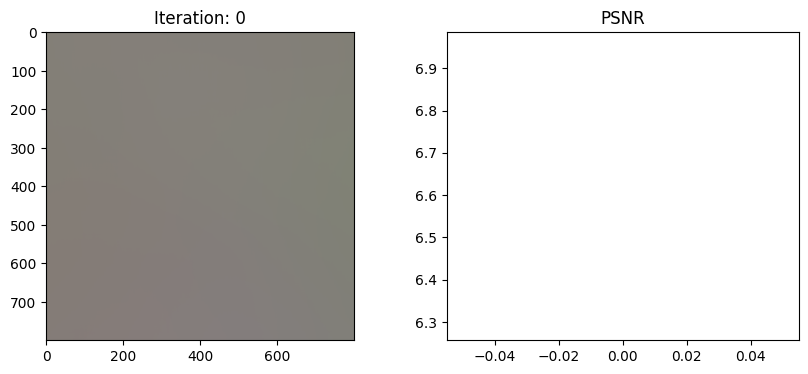

500 0.12851772499084474 secs per iter
Iteration 500: tensor(0., device='cuda:0')
Test MSE: 0.035636


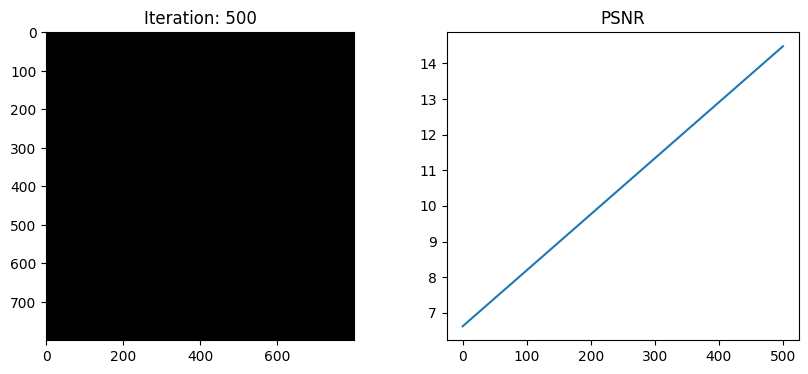

1000 0.1258869171142578 secs per iter
Iteration 1000: tensor(0., device='cuda:0')
Test MSE: 0.035636


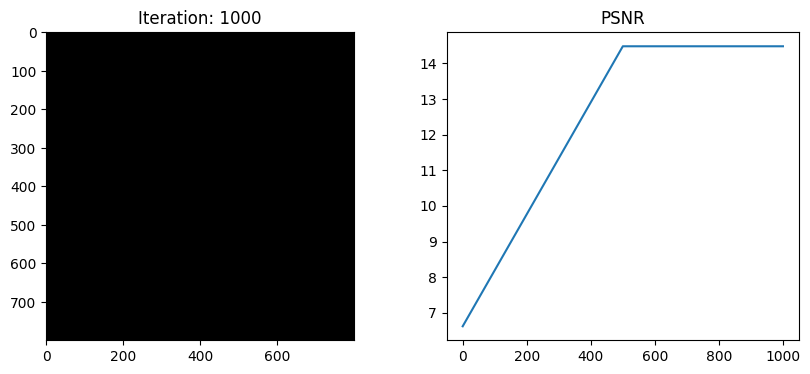

1500 0.13192893886566162 secs per iter
Iteration 1500: tensor(0., device='cuda:0')
Test MSE: 0.035636


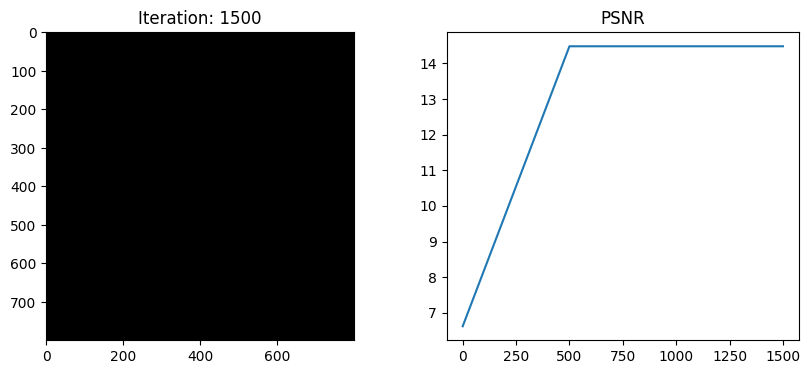

KeyboardInterrupt: 

In [12]:
torch.cuda.empty_cache()
t = time.time()
for i in range(N_iters + 1):

    # log_memory("iter_start")

    img_i = np.random.randint(images.shape[0])
    target = images[img_i].to(device)
    pose = poses[img_i].to(device)
    rays_o, rays_d = get_rays(H, W, focal, pose)


    coords = torch.stack(torch.meshgrid(torch.arange(H, device=device),torch.arange(W, device=device), indexing='ij'), -1).reshape(-1, 2)


    select_inds   = np.random.choice(coords.shape[0], size=[N_rand], replace=False)
    select_coords = coords[select_inds].long()
    rays_o_batch = rays_o[select_coords[:, 0], select_coords[:, 1]]
    rays_d_batch = rays_d[select_coords[:, 0], select_coords[:, 1]]
    target_s = target[select_coords[:, 0], select_coords[:, 1]]


    rgb_pred, _, _ = render_rays(model, rays_o_batch, rays_d_batch, near=2., far=6., N_samples=N_samples, rand=True)
    loss = torch.mean((rgb_pred - target_s) ** 2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # log_memory("after_train")


    if i%i_plot==0:
        with torch.no_grad():
            print(i, (time.time() - t) / i_plot, 'secs per iter')
            t = time.time()

            rays_o_test, rays_d_test = get_rays(H, W, focal, testpose.to(device))
            rgb, depth, acc = render_rays(model, rays_o_test, rays_d_test, near=2., far=6., N_samples=N_samples)
            loss_test = torch.mean((rgb - testimg.to(device)) ** 2)
            psnr = -10 * torch.log10(loss_test).item()
            psnrs.append(psnr)
            iternums.append(i)

            print(f"Iteration {i}:", torch.mean(rgb))
            print(f"Test MSE: {loss_test.item():.6f}")

            plt.figure(figsize=(10,4))
            plt.subplot(121)
            plt.imshow(rgb.detach().cpu().numpy())
            plt.title(f'Iteration: {i}')
            plt.subplot(122)
            plt.plot(iternums, psnrs)
            plt.title('PSNR')
            plt.show()

    torch.cuda.empty_cache()
   
torch.save(model.state_dict(), f"model_{dataset}_{N_iters_K}K.pth")

In [ ]:
model.load_state_dict(torch.load(f"model_{dataset}_{N_iters_K}K.pth"))

rays_o_test, rays_d_test = get_rays(H, W, focal, testpose.to(device))
rgb, depth, acc = render_rays(model, rays_o_test, rays_d_test, near=2., far=6., N_samples=N_samples)
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(rgb.detach().cpu().numpy())
plt.title(f'Iteration: 100000')

C:\Users\ninos\AppData\Local\Temp\ipykernel_6088\3633638608.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_100k_lego.pth"))


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.00 MiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 22.45 GiB is allocated by PyTorch, and 64.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
%matplotlib inline
from ipywidgets import interactive, widgets


trans_t = lambda t : torch.tensor([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,1,t],
    [0,0,0,1],
], dtype=torch.float32)

rot_phi = lambda phi : torch.tensor([
    [1,0,0,0],
    [0,torch.cos(torch.tensor(phi)),-torch.sin(torch.tensor(phi)),0],
    [0,torch.sin(torch.tensor(phi)), torch.cos(torch.tensor(phi)),0],
    [0,0,0,1],
], dtype=torch.float32)

rot_theta = lambda th : torch.tensor([
    [torch.cos(torch.tensor(th)),0,-torch.sin(torch.tensor(th)),0],
    [0,1,0,0],
    [torch.sin(torch.tensor(th)),0, torch.cos(torch.tensor(th)),0],
    [0,0,0,1],
], dtype=torch.float32)


def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(phi/180.*np.pi) @ c2w
    c2w = rot_theta(theta/180.*np.pi) @ c2w
    # Convert the numpy array to a torch tensor before multiplication
    c2w = torch.tensor([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]], dtype=torch.float32) @ c2w
    return c2w


def f(**kwargs):
    c2w = pose_spherical(**kwargs).to(device)
    focal_device = focal.to(device)
    rays_o, rays_d = get_rays(H, W, focal_device, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    img = np.clip(rgb,0,1)

    plt.figure(2, figsize=(20,6))
    plt.imshow(img)
    plt.show()


sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0] : sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

: 

In [10]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)
    c2w = c2w.to(device) # Move c2w to the correct device
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    frames.append((255*np.clip(rgb.detach().cpu().numpy(),0,1)).astype(np.uint8)) # Detach and move to CPU before numpy conversion

import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

  0%|          | 0/120 [00:20<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 40.00 MiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 22.34 GiB is allocated by PyTorch, and 137.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)